# PDF Text RAG 입문: 임베딩 벡터 + ChromaDB + Tool Calling

`PDF_Text_Data.zip`에서 **5개 PDF**만 골라, **텍스트 RAG**의 핵심 개념을 처음부터 따라 합니다.

## 이 노트북에서 배우는 것

| 개념 | 한 줄 설명 |
|------|------------|
| **RAG** | 질문과 관련된 문서를 **먼저 검색**한 뒤, 그 내용을 근거로 답을 만드는 방식 |
| **임베딩 벡터** | 문장·단락을 **숫자 배열(벡터)** 로 바꿔, 의미가 비슷하면 벡터도 가깝게 만드는 표현 |
| **벡터 DB** | 임베딩을 저장하고, 질문 벡터와 **가장 가까운** 문서를 빠르게 찾는 저장소 (ChromaDB) |
| **Tool Calling** | LLM Agent가 `search_documents` 같은 **함수(Tool)** 를 JSON으로 호출해 RAG 검색을 실행 |

## 전체 흐름

```
PDF_Text_Data.zip
       ↓
5개 PDF 선택 → PyMuPDF 텍스트 추출
       ↓
청크 분할 (500자 단위)
       ↓
Sentence-Transformers 임베딩 (384차원)
       ↓
ChromaDB 저장
       ↓
사용자 질문 → Tool Calling → search_documents → Top-k 청크
       ↓
검색 결과를 근거로 답변 생성
```

### Text RAG vs Visual RAG (01·12번 노트북)

| 구분 | 이 노트북 (Text RAG) | 01·12번 (Visual RAG) |
|------|----------------------|----------------------|
| 입력 | PDF에서 추출한 **텍스트** | **이미지** (프레임·PDF 페이지) |
| 임베딩 | Sentence-Transformers | SigLIP2 / ColPali |
| 검색 단위 | 텍스트 청크 | 이미지 1장 |
| Tool | `search_documents` | `search_conveyor`, `search_mvtec` 등 |

### 노트북 읽는 방법 (초보자용)

1. **위에서 아래로** 셀을 순서대로 실행합니다. (Run All도 가능)
2. 각 **## 번호** 구간 앞의 마크다운에서 "왜 필요한지·무엇을 하는지"를 먼저 읽습니다.
3. 코드 셀의 `#` 주석과 출력(표·유사도·Tool 로그)을 함께 보며 개념을 확인합니다.
4. **섹션 8**까지는 API Key 없이 동작합니다. **섹션 10**부터 OpenAI Key, **섹션 11**은 GPU(선택)가 필요합니다.

### 섹션별 구성

| 구간 | 주제 | 핵심 키워드 |
|------|------|-------------|
| 0~1 | 환경·데이터 준비 | import, ZIP, 5개 PDF |
| 2~3 | 전처리 | PyMuPDF, 청크, overlap |
| 4~5 | 임베딩·저장 | Sentence-Transformers, ChromaDB |
| 6 | RAG 검색 | Top-k, cosine 유사도, context |
| 7~8 | Tool Calling Agent | TOOL_SCHEMAS, Plan→Act→Answer |
| 10 | OpenAI LLM Agent | `.env`, `tools=`, Fallback |
| 11 (선택) | 로컬 Qwen Agent | Hugging Face, JSON Tool Calling |
| 12 | 정리 | FAQ, 다음 학습 경로 |

## 0. 환경 설정

이 섹션에서는 **RAG 파이프라인 전체에 쓰일 도구와 경로**를 한 번에 준비합니다.
코드를 실행하기 전에 "어떤 라이브러리가 왜 필요한지"를 이해하면, 이후 오류 메시지를 읽기 쉬워집니다.

### 왜 환경 설정이 먼저인가?

RAG는 한 번에 돌아가는 프로그램이 아니라 **여러 단계가 연결된 파이프라인**입니다.
PDF 읽기 → 텍스트 나누기 → 벡터 만들기 → DB 저장 → 검색 → Agent 답변.
각 단계마다 다른 라이브러리가 필요하므로, 맨 처음에 import와 폴더 경로를 고정해 두는 것이 좋습니다.

### 라이브러리 역할 (초보자용)

| 라이브러리 | 역할 | 비유 |
|------------|------|------|
| **PyMuPDF (`fitz`)** | PDF에서 글자 추출 | PDF를 "복사·붙여넣기" 가능한 텍스트로 바꾸는 도구 |
| **sentence-transformers** | 문장 → 숫자 벡터(임베딩) | 문장의 **의미를 좌표**로 바꿔 주는 번역기 |
| **ChromaDB** | 벡터 저장 + 유사도 검색 | 의미 좌표를 모아 두고 "가장 가까운 글"을 찾는 도서관 |
| **matplotlib** | 임베딩 2D 시각화 | 384차원 벡터를 눈으로 볼 수 있게 2D로 줄여 그림 |
| **pandas** | 표 형태 결과 출력 | 검색 결과·PDF 목록을 표로 보기 좋게 정리 |
| **openai / python-dotenv** | (섹션 10+) LLM API + API Key 로드 | 외부 AI에게 질문·답변을 맡길 때 사용 |

### 이 노트북에서 쓰는 주요 상수

| 상수 | 값 | 의미 |
|------|-----|------|
| `EMBED_MODEL_NAME` | `paraphrase-multilingual-MiniLM-L12-v2` | 한글·영문 지원, **384차원** 임베딩 |
| `CHUNK_SIZE` | 500 | 한 청크 최대 **글자 수** (토큰이 아님) |
| `CHUNK_OVERLAP` | 80 | 청크 경계가 문장 중간에서 잘리지 않도록 **겹침** |
| `TOP_K` | 3 | 질문당 가져올 **관련 청크 개수** |

### 폴더 구조

```
프로젝트 루트/
├── PDF_Text_Data.zip          ← 원본 데이터 (직접 배치)
└── data/pdf_text/
    ├── raw/                   ← ZIP 전체 해제
    ├── pdfs/                  ← 학습용 5개 PDF만 복사
    └── chroma_db/             ← 벡터 DB (재인덱싱 시 삭제·재생성)
```

### 사전 준비

- 프로젝트 루트에 `PDF_Text_Data.zip` 배치
- Jupyter 커널: **Python 3.10 이상** 권장
- 첫 실행 시 Hugging Face에서 임베딩 모델 가중치를 다운로드합니다 (인터넷 필요)

> **팁**: 셀을 **위에서부터 순서대로** 실행하세요. 중간 셀을 건너뛰면 `NameError`(변수 없음)가 날 수 있습니다.


In [1]:
# !pip install sentence-transformers pymupdf chromadb matplotlib pandas tqdm openai python-dotenv

# !py -3.11 -m pip install sentence-transformers
# [설명] 위 주석을 해제하면 현재 Jupyter 커널에 RAG·Agent 실행에 필요한 패키지를 설치합니다.


In [2]:
import json       # Tool call JSON 직렬화·파싱
import re         # PDF 텍스트 공백 정규화, JSON 블록 추출
import shutil     # ZIP 해제 폴더·ChromaDB 재인덱싱 시 삭제
import sys
import zipfile    # PDF_Text_Data.zip 압축 해제
from pathlib import Path  # OS 독립적 경로 처리

import chromadb   # 벡터 DB — 임베딩 저장·코사인 유사도 검색
import fitz  # PyMuPDF — PDF 페이지에서 텍스트 추출
import matplotlib.pyplot as plt  # 임베딩 PCA 시각화
import numpy as np
import pandas as pd       # PDF 목록·검색 결과 표 출력
from IPython.display import Markdown, display
from sentence_transformers import SentenceTransformer  # 텍스트 → 임베딩 벡터
from tqdm import tqdm     # ChromaDB 배치 저장 진행률

# --- 경로·상수 설정 ---
ROOT = Path(".").resolve()  # 노트북 실행 디렉터리(프로젝트 루트)
ZIP_PATH = ROOT / "PDF_Text_Data.zip"
RAW_DIR = ROOT / "data" / "pdf_text" / "raw"      # ZIP 전체 해제
PDF_DIR = ROOT / "data" / "pdf_text" / "pdfs"     # 학습용 5개 PDF
CHROMA_DIR = ROOT / "data" / "pdf_text" / "chroma_db"
COLLECTION_NAME = "pdf_text_rag"

# 입문용: 5개 PDF만 사용 (주제가 달라 검색 비교가 쉬움)
SELECTED_PDFS = [
    "AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf",
    "인공지능 활용 서울시 지하철 혼잡도 예측.pdf",
    "산업 IoT용 엣지컴퓨팅 기술 동향.pdf",
    "생활폐기물_사용자매뉴얼(지자체)_(텍스트기반).pdf",
    "장마 개념 재정립에 대한 논의.pdf",
]

EMBED_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"  # 384차원, 한글 지원
CHUNK_SIZE = 500       # 한 청크 최대 글자 수
CHUNK_OVERLAP = 80     # 인접 청크 겹침 — 문장 경계 잘림 완화
TOP_K = 3              # RAG 검색 시 반환할 청크 개수

PDF_DIR.mkdir(parents=True, exist_ok=True)
CHROMA_DIR.mkdir(parents=True, exist_ok=True)

# 한글 matplotlib (Windows 기본: Malgun Gothic)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

print(f"ROOT: {ROOT}")
print(f"ZIP 존재: {ZIP_PATH.exists()}")
print(f"선택 PDF: {len(SELECTED_PDFS)}개")


ROOT: C:\MyCursorLab\09_Visual_RAG
ZIP 존재: True
선택 PDF: 5개


## 1. ZIP 압축 해제 & 5개 PDF 선택

학습 데이터 ZIP을 풀고, **5개 PDF만** 골라 `data/pdf_text/pdfs/`에 둡니다.

### 이 단계가 하는 일

1. `PDF_Text_Data.zip` 전체(21개 PDF)를 `raw/`에 해제
2. 입문용으로 선정한 **5개 파일만** `pdfs/`로 복사
3. 파일 크기·이름을 표로 확인

### 왜 5개만 쓰나?

| 이유 | 설명 |
|------|------|
| **속도** | 임베딩·ChromaDB 저장·검색이 문서 수에 비례해 느려짐 |
| **비교 학습** | AI PaaS, 지하철, IoT, 폐기물, 장마 등 **주제가 달라** 검색 결과 차이를 보기 쉬움 |
| **디버깅** | 문제가 생겼을 때 원인 PDF를 빠르게 좁힐 수 있음 |

실무에서는 수천~수만 문서를 쓰지만, **개념 학습 단계**에서는 소량이 훨씬 효율적입니다.

### 기술 포인트: 한글 ZIP 파일명

Windows에서 만든 ZIP은 파일명을 **CP437 → CP949**로 다시 디코딩해야 한글이 깨지지 않습니다.
`decode_zip_name()` 함수가 이 인코딩 문제를 처리합니다.

### 선택된 5개 PDF

| 파일 | 주제 |
|------|------|
| AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf | 클라우드 AI 플랫폼 |
| 인공지능 활용 서울시 지하철 혼잡도 예측.pdf | 교통·머신러닝 |
| 산업 IoT용 엣지컴퓨팅 기술 동향.pdf | 스마트공장·엣지 |
| 생활폐기물_사용자매뉴얼(지자체)_(텍스트기반).pdf | 행정 매뉴얼 |
| 장마 개념 재정립에 대한 논의.pdf | 기상·학술 |

> **주의**: `ZIP_PATH.exists()`가 `False`이면 프로젝트 루트에 zip 파일 위치를 확인하세요.


In [3]:
def decode_zip_name(info: zipfile.ZipInfo) -> str:
    """Windows ZIP의 CP437/CP949 파일명 복원."""
    # 한글 Windows ZIP은 파일명을 CP437로 저장 → CP949로 디코딩해야 깨지지 않음
    try:
        return info.filename.encode("cp437").decode("cp949")
    except Exception:
        return info.filename


def extract_zip_to_raw(zip_path: Path, raw_dir: Path) -> None:
    """ZIP 전체를 raw_dir에 해제 (이미 있으면 스킵)."""
    if not zip_path.exists():
        raise FileNotFoundError(
            f"압축 파일 없음: {zip_path}\n프로젝트 루트에 PDF_Text_Data.zip을 두세요."
        )
    raw_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue
            name = decode_zip_name(info)
            target = raw_dir / Path(name).name  # 하위 경로 없이 파일명만 사용
            if target.exists():
                continue
            with zf.open(info) as src, open(target, "wb") as dst:
                dst.write(src.read())


def copy_selected_pdfs(raw_dir: Path, pdf_dir: Path, selected: list[str]) -> list[Path]:
    """SELECTED_PDFS 5개만 pdf_dir로 복사."""
    copied = []
    for name in selected:
        src = raw_dir / name
        if not src.exists():
            raise FileNotFoundError(f"선택 PDF 없음: {src}\n먼저 ZIP을 해제하세요.")
        dst = pdf_dir / name
        # 크기가 다르면 다시 복사 (손상·갱신 대응)
        if not dst.exists() or dst.stat().st_size != src.stat().st_size:
            shutil.copy2(src, dst)
        copied.append(dst)
    return copied


extract_zip_to_raw(ZIP_PATH, RAW_DIR)
pdf_paths = copy_selected_pdfs(RAW_DIR, PDF_DIR, SELECTED_PDFS)

df_pdfs = pd.DataFrame(
    [{"파일명": p.name, "크기(KB)": round(p.stat().st_size / 1024, 1)} for p in pdf_paths]
)
display(df_pdfs)


,파일명,크기(KB)
0,AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf,798.1
1,인공지능 활용 서울시 지하철 혼잡도 예측.pdf,1367.3
2,산업 IoT용 엣지컴퓨팅 기술 동향.pdf,1171.5
3,생활폐기물_사용자매뉴얼(지자체)_(텍스트기반).pdf,71.0
4,장마 개념 재정립에 대한 논의.pdf,703.1


## 2. PDF → 텍스트 추출

PDF 파일에서 **글자(텍스트)** 를 꺼내는 단계입니다. RAG의 "R(검색)"은 결국 **텍스트끼리** 비교하므로, 이 단계가 품질의 출발점입니다.

### PyMuPDF로 텍스트 추출

- `fitz.open(pdf)` : PDF 문서 열기
- `page.get_text("text")` : 해당 페이지의 **선택 가능한 텍스트** 추출
- 빈 페이지(스캔만 있는 경우)는 건너뜀

### Text RAG vs Visual RAG

| 구분 | 이 노트북 (Text RAG) | 12번 Visual RAG |
|------|----------------------|-----------------|
| PDF 처리 | **글자** 추출 | 페이지를 **이미지**로 렌더링 |
| 검색 대상 | 텍스트 청크 | 이미지 1장 |
| 적합한 PDF | 텍스트 레이어가 있는 PDF | 도표·사진이 많은 PDF |

**PyMuPDF**로 각 페이지의 텍스트를 읽습니다.
Visual RAG(12번)는 페이지를 **이미지**로 렌더링하지만, Text RAG는 **글자**를 추출합니다.

### 출력 데이터 구조

각 페이지는 아래 형태의 dict로 저장됩니다.

```python
{"page": 1, "text": "페이지 전체 텍스트..."}
```

나중에 청크를 만들 때 `page` 번호가 **출처(인용)** 로 쓰입니다.

### 한계와 주의

> 스캔 PDF(사진만 찍힌 PDF)는 텍스트가 거의 없을 수 있습니다. 이번 5개 문서는 텍스트 추출이 가능한 PDF입니다.

- 표·수식·각주는 한 줄로 뭉개질 수 있음 → 청크 분할·overlap으로 일부 완화
- OCR(광학 문자 인식)은 이 노트북 범위 밖 — 스캔 PDF는 별도 OCR 파이프라인 필요


In [4]:
def extract_pdf_pages(pdf_path: Path) -> list[dict]:
    """PDF 각 페이지 텍스트 추출 → [{page, text}, ...]."""
    doc = fitz.open(pdf_path)
    pages = []
    for page_no, page in enumerate(doc, start=1):
        text = page.get_text("text").strip()  # 순수 텍스트 모드
        if text:  # 빈 페이지(스캔만 있는 경우) 제외
            pages.append({"page": page_no, "text": text})
    return pages


sample_pdf = pdf_paths[1]  # 지하철 혼잡도 예측
sample_pages = extract_pdf_pages(sample_pdf)
print(f"문서: {sample_pdf.name}")
print(f"텍스트 있는 페이지: {len(sample_pages)} / {fitz.open(sample_pdf).page_count}")
print("\n--- 1페이지 미리보기 ---\n")
print(sample_pages[0]["text"][:600])


문서: 인공지능 활용 서울시 지하철 혼잡도 예측.pdf
텍스트 있는 페이지: 18 / 18

--- 1페이지 미리보기 ---

2025년도 KTX 수요 예측 및 정책적 의사결정   15
한국빅데이터학회지
제10권 제1호, 2025, pp. 15-32
https://doi.org/10.36498/kbigdt.2025.10.1.15
설명가능한 인공지능 활용 서울시 지하철 혼잡도 예측과 
정책적 의사결정 지원을 위한 비즈니스 애널리틱스
Business Analytics to Predict Seoul Subway Congestion 
and Policy Decision-making using Explainable AI
박재흥⋅김경원†
국립대학법인 인천대학교 글로벌정경대학 무역학부
요  약
2022년 기준 하루 평균 대중교통 이용 건수 약 1,025만 건 중에서 약 50.3%를 차지할 정도로 서울시민 
중 절반 이상이 매일 지하철을 이용한다. 본 연구는 시민들이 승하차하는 과정에서 느낄 수 있는 혼잡도를 
실시간으로 빠르고 정확하게 예측 및 설명함으로써 빅데이터 기반 실제 비즈니스의 활용도를 높이는 비즈니스 
애널리틱스 방법론을 제시하는 것을 목적으로 한다. 6개 공공데이터베이스를 융합하여 대표적인 머신러닝 
및 딥러닝 알고리즘으로 혼잡도를 예측하였고, 설명 가능한 인공지능인 SHAP 알고리


## 3. 청크(Chunk) 분할

긴 PDF 텍스트를 **작은 조각(청크)** 으로 나눕니다. RAG 검색은 "문서 전체"가 아니라 **청크 단위**로 이루어집니다.

### 왜 통째로 임베딩하지 않나?

| 문제 | 설명 |
|------|------|
| **검색 정밀도** | 50페이지 PDF 전체 벡터 1개 → "어느 부분이 관련 있는지" 알기 어려움 |
| **컨텍스트 길이** | LLM에 넣을 근거도 짧은 단락이 적합 (토큰 제한) |
| **유사도 희석** | 긴 글 하나의 벡터는 여러 주제가 섞여 **의미가 흐려짐** |

그래서 **500자** 정도의 작은 조각으로 나눈 뒤, 각 청크마다 별도 벡터를 만듭니다.

### 청크 분할 방식 (이 노트북)

```
페이지 텍스트
  → 공백 정규화 (줄바꿈·다중 공백 → 한 칸)
  → CHUNK_SIZE(500자)씩 자르기
  → CHUNK_OVERLAP(80자)만큼 되돌려 다음 청크 시작 (문맥 연속)
  → 80자 미만 짧은 조각은 제외
```

### 용어 정리

| 용어 | 설명 |
|------|------|
| **CHUNK_SIZE** | 한 청크 최대 **글자 수** (500) |
| **CHUNK_OVERLAP** | 인접 청크가 **겹치는** 글자 수 — 문장이 잘리는 것을 완화 |
| **메타데이터** | `source`(파일명), `page`(페이지 번호) — 검색 결과 **출처 표시**용 |

### 실무에서의 튜닝

- **CHUNK_SIZE를 크게** → 문맥은 길지만 검색이 거칠어질 수 있음
- **CHUNK_SIZE를 작게** → 정밀하지만 문장이 잘릴 수 있음 → overlap 증가
- 고급: 문장·단락 단위 분할(`RecursiveCharacterTextSplitter` 등)도 많이 사용

이 노트북 5개 PDF 기준 총 **약 300개** 청크가 생성됩니다.


In [5]:
def chunk_pages(pages: list[dict], source: str) -> list[dict]:
    """페이지 텍스트를 CHUNK_SIZE 단위로 분할."""
    chunks = []
    for page in pages:
        text = re.sub(r"\s+", " ", page["text"])  # 줄바꿈·다중 공백 → 한 칸
        start = 0
        while start < len(text):
            end = min(len(text), start + CHUNK_SIZE)
            piece = text[start:end].strip()
            if len(piece) >= 80:  # 너무 짧은 조각은 검색 품질이 낮음
                chunks.append({
                    "source": source,   # PDF 파일명 (출처 표시용)
                    "page": page["page"],
                    "text": piece,
                })
            if end >= len(text):
                break
            start = end - CHUNK_OVERLAP  # overlap만큼 되돌려 문맥 연속성 유지
    return chunks


all_chunks: list[dict] = []
for pdf_path in pdf_paths:
    pages = extract_pdf_pages(pdf_path)
    all_chunks.extend(chunk_pages(pages, pdf_path.name))

print(f"총 청크 수: {len(all_chunks)}")
print(f"예시 청크:\n{all_chunks[0]['text'][:200]}...")


총 청크 수: 300
예시 청크:
- 2 - 본 제작물은 디지털서비스 이용지원시스템이 저작권을 보유하고 있습니다. 디지털서비스 이용지원시스템의 승인 없이 이슈리포트의 내용 일부 또는 전부를 다른 목적으로 이용할 수 없습니다. 디지털서비스 이슈리포트 01 AI PaaS의 필요성과 글로벌 AI PaaS 동향 3 │김혜영 한국지능정보사회진흥원 책임연구원 │정기봉 (주)이노그리드 이사 02 책임 ...


## 4. 임베딩 벡터란?

**임베딩(Embedding)** 은 텍스트를 컴퓨터가 비교할 수 있는 **숫자 배열(벡터)** 로 바꾸는 과정입니다. Text RAG의 핵심 개념입니다.

### 한 줄 정의

> 의미가 비슷한 문장 → 벡터 공간에서 **가까운 위치** → 검색 시 함께 찾아짐

### 변환 예시

```
"지하철 혼잡도 예측"  →  [0.12, -0.03, 0.41, ..., 0.08]  (384개 숫자)
"AI PaaS 플랫폼 동향"  →  [0.09,  0.11, 0.22, ..., 0.15]
```

- **의미가 비슷한 문장** → 벡터 방향이 가까움 → **코사인 유사도**가 높음
- **의미가 다른 문장** → 벡터 방향이 멀음 → 유사도가 낮음
- **RAG 검색** = 질문 벡터와 **가장 가까운 청크 벡터** Top-k개를 찾는 것

### 사용 모델

`paraphrase-multilingual-MiniLM-L12-v2`

| 항목 | 값 |
|------|-----|
| 차원 | **384** (숫자 384개) |
| 언어 | 한글·영문 등 **다국어** |
| 실행 | CPU 가능 (GPU 없어도 입문 실습 가능) |

### 코사인 유사도 (Cosine Similarity)

두 벡터 사이 **각도**가 작을수록 유사도 ↑ (1에 가까울수록 비슷).

- `normalize_embeddings=True` : 벡터 길이를 1로 맞춤 → 코사인 유사도 = **내적(dot product)** 로 간단히 계산
- 아래 셀에서 같은 주제(지하철) vs 다른 주제(장마) 유사도를 직접 비교합니다

### PCA 시각화 (다음 셀)

384차원은 사람이 볼 수 없으므로 **PCA(SVD)** 로 2차원에 투영합니다.
같은 PDF에서 나온 청크들이 scatter plot에서 **가까이 모이는지** 확인하면 임베딩 품질을 직관적으로 이해할 수 있습니다.

> PCA 그림은 **개념 이해용**이며, 실제 검색은 384차원 전체에서 이루어집니다.


In [6]:
embedder = SentenceTransformer(EMBED_MODEL_NAME)  # 첫 실행 시 HF에서 가중치 다운로드

# 유사·비유사 문장 3개로 코사인 유사도 체험
demo_sentences = [
    "서울 지하철 혼잡도를 인공지능으로 예측한다",
    "지하철 승객 수요 예측 모델",
    "장마철 강수량과 기상 조건",
]
demo_vecs = embedder.encode(demo_sentences, normalize_embeddings=True)


def cosine_sim(a, b):
    # L2 정규화된 벡터 → 코사인 유사도 = 내적
    return float(np.dot(a, b))


print(f"임베딩 차원: {demo_vecs.shape[1]}")
print(f"\n유사도(질문1 vs 질문2, 같은 주제): {cosine_sim(demo_vecs[0], demo_vecs[1]):.3f}")
print(f"유사도(질문1 vs 질문3, 다른 주제): {cosine_sim(demo_vecs[0], demo_vecs[2]):.3f}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

임베딩 차원: 384

유사도(질문1 vs 질문2, 같은 주제): 0.653
유사도(질문1 vs 질문3, 다른 주제): 0.194


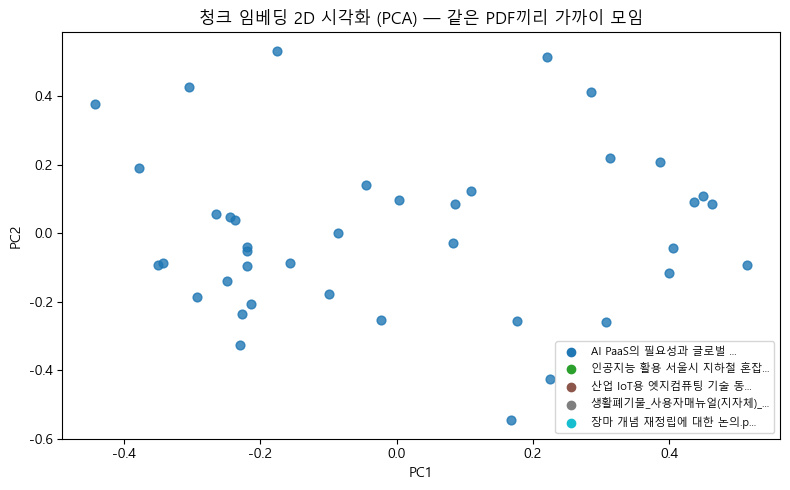

In [7]:
# PCA로 384차원 → 2차원 축소 후 시각화 (개념 이해용)
sample_texts = [c["text"][:120] for c in all_chunks[:40]]
sample_labels = [c["source"][:12] + "..." for c in all_chunks[:40]]
sample_vecs = embedder.encode(sample_texts, normalize_embeddings=True)

# SVD로 주성분 2축 추출 (sklearn 없이 numpy만 사용)
mean = sample_vecs.mean(axis=0)
centered = sample_vecs - mean
u, s, vt = np.linalg.svd(centered, full_matrices=False)
coords = centered @ vt[:2].T  # (N, 2) 2D 좌표

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(pdf_paths)))
source_to_color = {p.name: colors[i] for i, p in enumerate(pdf_paths)}
for i, c in enumerate(all_chunks[:40]):
    ax.scatter(coords[i, 0], coords[i, 1], c=[source_to_color[c["source"]]], s=40, alpha=0.8)
ax.set_title("청크 임베딩 2D 시각화 (PCA) — 같은 PDF끼리 가까이 모임")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
for name, color in source_to_color.items():
    ax.scatter([], [], c=[color], label=name[:18] + "...")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()


## 5. ChromaDB에 임베딩 저장

모든 청크를 임베딩한 뒤 **ChromaDB**에 저장합니다. 이후 질문이 오면 DB에서 **가장 유사한 청크**를 빠르게 찾습니다.

### 벡터 DB란?

일반 DB는 "정확히 일치하는 값"을 찾지만, 벡터 DB는 **의미적으로 가까운** 벡터를 찾습니다.

```
[인덱싱] 300개 청크 → 300개 384차원 벡터 → ChromaDB 저장
[검색]   질문 1개 → 질문 벡터 1개 → DB에서 Top-k 유사 청크 반환
```

### ChromaDB에 저장되는 것

| 필드 | 내용 |
|------|------|
| `ids` | `chunk_0000`, `chunk_0001`, ... (고유 ID) |
| `embeddings` | 384차원 벡터 리스트 |
| `documents` | 원본 청크 텍스트 |
| `metadatas` | `source`, `page`, `preview` (출처·미리보기) |

### 주요 설정

| 설정 | 값 | 의미 |
|------|-----|------|
| `hnsw:space` | `cosine` | **코사인 거리**로 유사도 계산 (거리 = 1 − 유사도) |
| `normalize_embeddings=True` | L2 정규화 | cosine ≈ 내적, 검색 안정 |
| `PersistentClient` | 디스크 저장 | 노트북 재실행해도 **인덱스 유지** (`chroma_db/` 폴더) |

### HNSW (개념)

ChromaDB 내부는 **HNSW** 그래프로 근사 최근접 이웃(ANN) 검색을 합니다.
수백~수만 청크에서는 **전부 비교**하지 않고도 빠르게 Top-k를 찾을 수 있습니다.

### 재인덱싱

`reset=True`이면 기존 `chroma_db/` 폴더를 **삭제 후 재생성**합니다.
PDF·청크 설정을 바꾼 뒤에는 반드시 이 셀을 다시 실행하세요.

> **팁**: `collection.count()`로 저장된 청크 수(약 300)가 맞는지 확인하세요.


In [8]:
def build_chroma_index(chunks: list[dict], embedder: SentenceTransformer, reset: bool = True):
    """청크 임베딩을 ChromaDB에 일괄 저장."""
    if reset and CHROMA_DIR.exists():
        shutil.rmtree(CHROMA_DIR)  # 재인덱싱 시 기존 DB 삭제
        CHROMA_DIR.mkdir(parents=True, exist_ok=True)

    client = chromadb.PersistentClient(path=str(CHROMA_DIR))  # 디스크 영구 저장
    collection = client.get_or_create_collection(
        name=COLLECTION_NAME,
        metadata={"hnsw:space": "cosine"},  # 코사인 거리 = 1 - 유사도
    )

    texts = [c["text"] for c in chunks]
    embeddings = embedder.encode(texts, show_progress_bar=True, normalize_embeddings=True)

    ids = [f"chunk_{i:04d}" for i in range(len(chunks))]
    metadatas = [
        {"source": c["source"], "page": c["page"], "preview": c["text"][:120]}
        for c in chunks
    ]

    batch = 64  # 한 번에 add할 청크 수 (메모리·속도 균형)
    for i in tqdm(range(0, len(ids), batch), desc="ChromaDB 저장"):
        sl = slice(i, i + batch)
        collection.add(
            ids=ids[sl],
            embeddings=embeddings[sl].tolist(),
            documents=texts[sl],
            metadatas=metadatas[sl],
        )
    return collection


collection = build_chroma_index(all_chunks, embedder, reset=True)
print(f"인덱싱 완료: {collection.count()} 청크")


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

ChromaDB 저장: 100%|██████████| 5/5 [00:00<00:00,  8.53it/s]

인덱싱 완료: 300 청크


## 6. RAG 검색 — 질문 → 관련 청크

**RAG(Retrieval-Augmented Generation)** 의 **Retrieval(검색)** 단계입니다. 사용자 질문과 **의미가 가까운** 문서 조각을 찾아옵니다.

### RAG 전체 그림

```
[Retrieval]  질문 → 벡터 검색 → 관련 청크 Top-k     ← 이 섹션
[Augmented]  검색 결과를 LLM 프롬프트에 "근거"로 첨부
[Generation] LLM이 근거만 보고 답변 생성            ← 섹션 8·10·11
```

LLM만 쓰면 **학습 데이터에 없는 최신 PDF 내용**을 모릅니다.
RAG는 먼저 PDF에서 관련 글을 찾고, 그걸 근거로 답하게 합니다 → **환각(hallucination) 감소**.

### 검색 3단계

1. 사용자 **질문**을 같은 임베딩 모델로 **벡터화**
2. ChromaDB에서 **Top-k** (기본 3개) 유사 청크 검색
3. 검색된 텍스트를 LLM(또는 규칙 기반) 답변의 **근거(context)** 로 사용

### `search_documents()` 동작

| 단계 | 코드 | 설명 |
|------|------|------|
| 질문 임베딩 | `embedder.encode([query])` | 질문 → 384차원 벡터 |
| 필터 (선택) | `where={"source": "파일명.pdf"}` | 특정 PDF만 검색 |
| 쿼리 | `collection.query(...)` | Top-k + 거리(distance) 반환 |
| 유사도 | `1.0 - dist` | cosine distance → similarity |

### `synthesize_answer()` (다음 셀)

입문용 **규칙 기반** 답변: LLM 없이 검색 청크를 묶어 Markdown으로 보여 줍니다.
실무에서는 이 context를 GPT·Qwen 등에 넣어 **자연스러운 문장**으로 생성합니다.

### 유사도 해석 (경험칙)

| 유사도 | 의미 |
|--------|------|
| 0.7 이상 | 같은 주제로 강하게 매칭 |
| 0.4~0.7 | 관련 있으나 문맥 확인 필요 |
| 0.3 미만 | 거의 무관 — 질문·문서·청크 설정 점검 |

> **팁**: `demo_query`를 바꿔 보고, **올바른 PDF**의 청크가 상위에 오는지 확인해 보세요.


In [9]:
def search_documents(query: str, top_k: int = TOP_K, source_filter: str | None = None) -> list[dict]:
    """질문 벡터로 ChromaDB Top-k 유사 청크 검색."""
    query_vec = embedder.encode([query], normalize_embeddings=True)[0].tolist()
    where = {"source": source_filter} if source_filter else None  # 특정 PDF만 검색
    result = collection.query(
        query_embeddings=[query_vec],
        n_results=top_k,
        where=where,
        include=["documents", "metadatas", "distances"],
    )
    hits = []
    for doc, meta, dist in zip(
        result["documents"][0], result["metadatas"][0], result["distances"][0]
    ):
        hits.append({
            "text": doc,
            "source": meta["source"],
            "page": meta["page"],
            "similarity": round(1.0 - dist, 3),  # cosine: similarity = 1 - distance
        })
    return hits


demo_query = "지하철 혼잡도는 어떻게 예측하나요?"
demo_hits = search_documents(demo_query)

rows = [
    {
        "유사도": h["similarity"],
        "출처": h["source"][:24] + "...",
        "페이지": h["page"],
        "내용": h["text"][:80] + "...",
    }
    for h in demo_hits
]
display(pd.DataFrame(rows))


,유사도,출처,페이지,내용
0,0.717,인공지능 활용 서울시 지하철 혼잡도 예측.p...,17,"/2753-8818/13/20240853 [17] K. Kim, S. Park, S..."
1,0.695,인공지능 활용 서울시 지하철 혼잡도 예측.p...,14,정책 제 안보다는 복합적인 정책 제안에 활용하는 것 을 추천한다. (가) 우선순위 ...
2,0.692,인공지능 활용 서울시 지하철 혼잡도 예측.p...,12,가 지하철 혼잡도에 어떠한 방향성을 가지는지 일반화하는 것은 다소 위 험할 수 있다...


In [10]:
def synthesize_answer(query: str, hits: list[dict]) -> str:
    """입문용: LLM 없이 검색 결과를 묶어 간단 답변 생성."""
    if not hits:
        return "관련 문서를 찾지 못했습니다."
    # 검색 청크를 하나의 context 문자열로 합침
    context = "\n\n".join(
        f"[{i+1}] ({h['source']} p.{h['page']}, sim={h['similarity']})\n{h['text'][:350]}"
        for i, h in enumerate(hits)
    )
    top = hits[0]  # 유사도 1위 청크
    return (
        f"**질문**: {query}\n\n"
        f"**요약**: 검색 결과 `{top['source']}` (p.{top['page']})가 가장 관련 있습니다.\n\n"
        f"**근거 발췌**:\n{context}\n\n"
        "*실무에서는 위 context를 GPT·Qwen·Claude 등 LLM에 넣어 자연스러운 답변을 생성합니다.*"
    )


display(Markdown(synthesize_answer(demo_query, demo_hits)))


**질문**: 지하철 혼잡도는 어떻게 예측하나요?

**요약**: 검색 결과 `인공지능 활용 서울시 지하철 혼잡도 예측.pdf` (p.17)가 가장 관련 있습니다.

**근거 발췌**:
[1] (인공지능 활용 서울시 지하철 혼잡도 예측.pdf p.17, sim=0.717)
/2753-8818/13/20240853 [17] K. Kim, S. Park, S. Choi, and Y. Kim, “A Study on Dynamic Analysis and Prediction Modeling of Subway Station Congestion Changes Using Deep Learning Analysis,” in Proceedings of Symposium of the Korean Institute of communica- tions and Information Sciences, 2024, pp. 1192-1194. [18] X. Tian, C. Zhang, and B. Zheng, “Fine-

[2] (인공지능 활용 서울시 지하철 혼잡도 예측.pdf p.14, sim=0.695)
정책 제 안보다는 복합적인 정책 제안에 활용하는 것 을 추천한다. (가) 우선순위 1-12 (나) 우선순위 13-23 <그림 3> 지하철 혼잡도 예측에 대한 변수들의 기여 설명력 기반 의사결정 Ⅳ. 결론 최근 전 세계적으로 확산하였던 코로나바이 러스 역시 사람들이 밀집되는 폐쇄적 대중교통 에서 강한 전염성을 보여 지하철 이용이 크게

[3] (인공지능 활용 서울시 지하철 혼잡도 예측.pdf p.12, sim=0.692)
가 지하철 혼잡도에 어떠한 방향성을 가지는지 일반화하는 것은 다소 위 험할 수 있다. 정책적 근거를 위해 일시적으 로 사용할 수는 있겠지만 정책 입안자들 또는 시민들에게 이해될만한 정보로 실시간으로

*실무에서는 위 context를 GPT·Qwen·Claude 등 LLM에 넣어 자연스러운 답변을 생성합니다.*

## 7. Tool Calling — RAG를 Agent Tool로 감싸기

LLM **Agent**가 RAG 검색을 직접 하지 않고, **`search_documents` 같은 Tool**을 JSON으로 호출하게 만드는 단계입니다.

### Agent + Tool Calling이란?

| 역할 | 담당 |
|------|------|
| **LLM (두뇌)** | "무엇을 검색할지" 계획 — Tool 이름 + 인자 JSON 생성 |
| **Python (손)** | `toolbox.dispatch()`로 실제 ChromaDB 검색 실행 |
| **Tool Schema** | LLM에게 "쓸 수 있는 함수 목록·파라미터"를 알려 주는 **설명서** |

LLM Agent는 직접 벡터 DB를 다루지 않습니다.
대신 **`search_documents` Tool** 을 JSON으로 호출하고, Python이 실제 검색을 실행합니다.

### Tool 호출 JSON 예시

```json
[
  {"name": "search_documents", "arguments": {"query": "엣지 컴퓨팅이란?", "top_k": 3}}
]
```

### 등록된 Tool (이 노트북)

| Tool | 역할 |
|------|------|
| `search_documents` | 질문·top_k·source_filter로 **벡터 검색** |
| `list_documents` | 인덱싱된 PDF 목록·청크 수 **조회** |

### `DocumentToolBox`

OpenAI **function calling**과 같은 인터페이스로 Python 함수를 감쌉니다.

```
TOOL_SCHEMAS (LLM이 읽는 설명)
       ↓
plan: tool_calls JSON 생성
       ↓
dispatch(name, arguments) → search_documents() / list_documents()
       ↓
observation (검색 결과 dict) → LLM 또는 답변 생성기로 전달
```

### 실무 흐름

1. LLM이 `TOOL_SCHEMAS`를 읽음
2. 사용자 질문에 맞는 Tool + 인자 JSON 생성 (`tool_calls`)
3. `dispatch()`가 Python 함수 실행
4. 검색 결과를 LLM에 다시 전달 → 최종 답변

> 이 노트북 **섹션 8**은 **LLM API 없이** 키워드 기반 `plan_tools()`로 Tool Calling 프로토콜을 시뮬레이션합니다.
> **섹션 10**에서 OpenAI API로, **섹션 11 (선택)**에서 로컬 Qwen3-4B로 LLM Tool Calling을 연결합니다.


In [11]:
# OpenAI function calling 형식 — LLM이 읽고 tool_calls JSON을 생성
TOOL_SCHEMAS: list[dict] = [
    {
        "type": "function",
        "function": {
            "name": "search_documents",
            "description": "PDF 문서 청크 Vector DB에서 질문과 관련된 텍스트를 검색합니다.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {"type": "string", "description": "검색 질문 또는 키워드"},
                    "top_k": {"type": "integer", "default": 3},
                    "source_filter": {
                        "type": "string",
                        "description": "특정 PDF 파일명으로 범위 제한 (선택)",
                    },
                },
                "required": ["query"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "list_documents",
            "description": "인덱싱된 PDF 목록과 청크 수를 조회합니다.",
            "parameters": {"type": "object", "properties": {}},
        },
    },
]

print("등록 Tool:", ", ".join(t["function"]["name"] for t in TOOL_SCHEMAS))
print("\nSchema 예시:")
print(json.dumps(TOOL_SCHEMAS[0], ensure_ascii=False, indent=2))


등록 Tool: search_documents, list_documents

Schema 예시:
{
  "type": "function",
  "function": {
    "name": "search_documents",
    "description": "PDF 문서 청크 Vector DB에서 질문과 관련된 텍스트를 검색합니다.",
    "parameters": {
      "type": "object",
      "properties": {
        "query": {
          "type": "string",
          "description": "검색 질문 또는 키워드"
        },
        "top_k": {
          "type": "integer",
          "default": 3
        },
        "source_filter": {
          "type": "string",
          "description": "특정 PDF 파일명으로 범위 제한 (선택)"
        }
      },
      "required": [
        "query"
      ]
    }
  }
}


In [12]:
class DocumentToolBox:
    """Text RAG Tool 실행기 — OpenAI function calling과 동일 인터페이스."""

    def __init__(self, collection, embedder, pdf_paths: list[Path], chunks: list[dict]):
        self.collection = collection
        self.embedder = embedder
        self.pdf_paths = pdf_paths
        # Chroma count(where=) 미지원 → 청크 리스트에서 PDF별 개수 집계
        self.chunk_counts = {}
        for c in chunks:
            self.chunk_counts[c["source"]] = self.chunk_counts.get(c["source"], 0) + 1

    def search_documents(self, query: str, top_k: int = TOP_K, source_filter: str | None = None) -> dict:
        hits = search_documents(query, top_k=top_k, source_filter=source_filter)
        return {"tool": "search_documents", "query": query, "results": hits}

    def list_documents(self) -> dict:
        rows = []
        for p in self.pdf_paths:
            cnt = self.chunk_counts.get(p.name, 0)
            rows.append({"source": p.name, "chunks": cnt})
        return {"tool": "list_documents", "documents": rows, "total_chunks": self.collection.count()}

    def dispatch(self, name: str, arguments: dict) -> dict:
        """Tool 이름 → Python 메서드 동적 호출 (Agent Act 단계)."""
        fn = getattr(self, name, None)
        if fn is None:
            return {"error": f"Unknown tool: {name}"}
        return fn(**arguments)


toolbox = DocumentToolBox(collection, embedder, pdf_paths, all_chunks)
display(pd.DataFrame(toolbox.list_documents()["documents"]))


,source,chunks
0,AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf,120
1,인공지능 활용 서울시 지하철 혼잡도 예측.pdf,87
2,산업 IoT용 엣지컴퓨팅 기술 동향.pdf,39
3,생활폐기물_사용자매뉴얼(지자체)_(텍스트기반).pdf,20
4,장마 개념 재정립에 대한 논의.pdf,34


## 8. Agent 루프 — Plan → Act → Answer

검색 + 답변을 **Agent 루프**로 묶습니다. LLM 없이 **키워드 규칙**으로 Tool Calling 전체 흐름을 체험합니다.

### Agent 3단계 (ReAct 패턴과 유사)

```
Plan   → 어떤 Tool을 어떤 인자로 호출할지 결정
Act    → toolbox.dispatch()로 Tool 실행
Answer → 검색 결과(observation)를 바탕으로 답변 생성
```

1. **Plan**: 사용자 질문 → 어떤 Tool을 호출할지 결정 (여기서는 **키워드 규칙**)
2. **Act**: `toolbox.dispatch()`로 Tool 실행
3. **Answer**: 검색 결과를 종합해 Markdown 답변 생성

### `plan_tools()` — 교육용 Planner

실무에서는 LLM이 `TOOL_SCHEMAS`를 보고 Plan을 만듭니다.
이 노트북 섹션 8은 **API 비용 없이** 프로토콜만 익히기 위해 규칙 기반입니다.

| 질문 키워드 | `source_filter` (검색 범위) |
|-------------|----------------------------|
| 장마, 기상 | 장마 개념 재정립에 대한 논의.pdf |
| 폐기물, 재활용 | 생활폐기물_사용자매뉴얼...pdf |
| iot, 엣지 | 산업 IoT용 엣지컴퓨팅...pdf |
| paas, 플랫폼 | AI PaaS의 필요성과...pdf |

항상 `list_documents` → `search_documents` 순으로 호출합니다.

### `TextRAGAgent.run()` 반환값

```python
{
  "plan": [...],           # Tool call 계획
  "observations": [...], # 각 Tool 실행 결과
  "answer": "Markdown..." # 최종 답변
}
```

### 이 섹션의 한계 (의도적)

- Planner가 **키워드**에 의존 → "지하철"처럼 필터 없는 질문은 5개 PDF 전체 검색
- Answer가 **규칙 기반** → 문장이 자연스럽지 않음 (섹션 10·11에서 LLM으로 개선)

> **학습 포인트**: 콘솔에 `▶ Tool: search_documents(...)` 로그가 보이면 Plan→Act가 정상 동작한 것입니다.


In [13]:
def synthesize_answer(query: str, hits: list[dict]) -> str:
    """입문용: LLM 없이 검색 결과를 묶어 간단 답변 생성."""
    if not hits:
        return "관련 문서를 찾지 못했습니다."
    context = "\n\n".join(
        f"[{i+1}] ({h['source']} p.{h['page']}, sim={h['similarity']})\n{h['text'][:350]}"
        for i, h in enumerate(hits)
    )
    top = hits[0]
    return (
        f"**질문**: {query}\n\n"
        f"**요약**: 검색 결과 `{top['source']}` (p.{top['page']})가 가장 관련 있습니다.\n\n"
        f"**근거 발췌**:\n{context}\n\n"
        "*실무에서는 위 context를 GPT·Qwen·Claude 등 LLM에 넣어 자연스러운 답변을 생성합니다.*"
    )


def plan_tools(user_query: str) -> list[dict]:
    """교육용 Tool call 계획 (실무: LLM이 TOOL_SCHEMAS를 보고 생성)."""
    q = user_query.lower()
    calls = [{"name": "list_documents", "arguments": {}}]  # 인덱스 확인 Tool

    # 키워드 → PDF source_filter 매핑 (입문용 규칙 Planner)
    source_filter = None
    if "장마" in user_query or "기상" in user_query:
        source_filter = "장마 개념 재정립에 대한 논의.pdf"
    elif "폐기물" in user_query or "재활용" in user_query:
        source_filter = "생활폐기물_사용자매뉴얼(지자체)_(텍스트기반).pdf"
    elif "iot" in q or "엣지" in user_query:
        source_filter = "산업 IoT용 엣지컴퓨팅 기술 동향.pdf"
    elif "paas" in q or "플랫폼" in user_query:
        source_filter = "AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf"

    args = {"query": user_query, "top_k": TOP_K}
    if source_filter:
        args["source_filter"] = source_filter
    calls.append({"name": "search_documents", "arguments": args})
    return calls


class TextRAGAgent:
    """Plan → Act → Answer 키워드 기반 Agent."""

    def run(self, user_query: str) -> dict:
        plan = plan_tools(user_query)
        observations = []
        for step in plan:
            obs = toolbox.dispatch(step["name"], step["arguments"])
            observations.append(obs)
            print(f"▶ Tool: {step['name']}({json.dumps(step['arguments'], ensure_ascii=False)})")

        search_obs = next(o for o in observations if o.get("tool") == "search_documents")
        hits = search_obs.get("results", [])
        answer = synthesize_answer(user_query, hits)
        return {"plan": plan, "observations": observations, "answer": answer}


agent = TextRAGAgent()


In [14]:
test_questions = [
    "AI PaaS란 무엇이고 왜 필요한가요?",
    "산업 현장에서 엣지 컴퓨팅은 어떤 역할을 하나요?",
    "생활폐기물 배출 절차는 어떻게 되나요?",
    "장마의 정의는 무엇인가요?",
]

for q in test_questions:
    print("=" * 60)
    print(f"질문: {q}")
    result = agent.run(q)
    display(Markdown(result["answer"]))
    print()


질문: AI PaaS란 무엇이고 왜 필요한가요?
▶ Tool: list_documents({})
▶ Tool: search_documents({"query": "AI PaaS란 무엇이고 왜 필요한가요?", "top_k": 3, "source_filter": "AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf"})


**질문**: AI PaaS란 무엇이고 왜 필요한가요?

**요약**: 검색 결과 `AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf` (p.8)가 가장 관련 있습니다.

**근거 발췌**:
[1] (AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf p.8, sim=0.788)
환경을 제공하고 있다. 마무리 본 보고서에서 살펴본 바와 같이, PaaS의 발전은 단순히 DevOps 중심의 애플리케이션 개발 편의성과 운영 안정성 지원을 넘어, 생성형 AI 기술의 급속한 발전과 AI 서비스 수요 급증에 대응하기 위해 지속적인 모델 학습과 고도화를 플랫폼 차원에서 지원하는 AI PaaS로의 진화로 이어지고 있다. 이에 발맞춰, 글로벌 빅테크 기업들은 이미 막대한 시장 점유율을 바탕으로 확보한 자원을 재투자하며, AI PaaS 시장 선점을 위한 전략적 행보를 가속화하고 있다. 현재에도 선두 지위를 공고히 하기 위해 대규모 투자를 지속해서 확대하는 추세다.

[2] (AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf p.6, sim=0.774)
공했다면, AI PaaS는 GPU, TPU, NPU 등 AI 연산에 특화된 하드웨어를 중심으로 설계된다. 스토리지 역시 기존의 관계형 데이터베이스나 NoSQL에서 벗어나 대용량 데이터 처리를 위한 데이터 레이크, 벡터 검색을 위한 벡터 데이터베이스, 분산 파일 시스템으로 확장된다. 네트워킹 또한 단순한 HTTP/REST API를 넘어 대용량 모델 서빙과 실시간 스트리밍 추론을 위한 고대역폭 통신을 지원해야 한다. Ÿ 개발 및 운영 프로세스 관점 기존 DevOps에 MLOps(머신러닝 운영)와 DataOps(데이터 운영)가 추가된다는 것이 가장 큰 특징이다. 코드 관리는 Git 기반의 소스코드 버전 관리를 넘어 학습 데이

[3] (AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf p.3, sim=0.77)
디지털서비스 이슈리포트 - 3 - 01 AI PaaS의 필요성과 글로벌 AI PaaS 동향 │김혜영 한국지능정보사회진흥원 책임연구원 │정기봉 (주)이노그리드 이사 PaaS의 등장과 역할 PaaS(Platform as a Service)는 애플리케이션 개발과 배포에 필요한 플랫폼과 개발도구를 클라우드 환경에서 서비스의 형태로 제공하는 컴퓨팅 모델이다. 이를 통해 개발자는 인프라 구축과 관리에 신경 쓰지 않고 애플리케이션 개발에만 집중할 수 있어 개발 생산성과 효율성을 크게 향상시킬 수 있다. 2010년대 중반 이후 핀테크, 이커머스, 게임 산업이 급성장하면서 빠른 서비스 출시와 확장성이 기업 경쟁력의 핵심 요소로 부상했다

*실무에서는 위 context를 GPT·Qwen·Claude 등 LLM에 넣어 자연스러운 답변을 생성합니다.*


질문: 산업 현장에서 엣지 컴퓨팅은 어떤 역할을 하나요?
▶ Tool: list_documents({})
▶ Tool: search_documents({"query": "산업 현장에서 엣지 컴퓨팅은 어떤 역할을 하나요?", "top_k": 3, "source_filter": "산업 IoT용 엣지컴퓨팅 기술 동향.pdf"})


**질문**: 산업 현장에서 엣지 컴퓨팅은 어떤 역할을 하나요?

**요약**: 검색 결과 `산업 IoT용 엣지컴퓨팅 기술 동향.pdf` (p.1)가 가장 관련 있습니다.

**근거 발췌**:
[1] (산업 IoT용 엣지컴퓨팅 기술 동향.pdf p.1, sim=0.728)
확대할것으로보고있고, 제조서 비스화를통하여국내산업경쟁력강화를가져올것으로 기대하고있다[1]. 기존의일반공장에서는공장의여러생산설비를제어 시스템을통하여연결과관리를통하여자동으로공장을관 리하였다면스마트공장에서는기존의자동화에서더나아 가서IT(Information Technology) 기술과OT(Operation Tech- nology) 기술의융합을통하여지능화제공을목표로하고 있다. 이러한IT 기술과OT 기술의융합을통한지능화는 공장의여러생산설비를센서및사물인터넷기술을통하 여연결하고, 수집된데이터를분석하여최적의상황을미 리예측하여공장을관리하는것을목표로함으로써, 공장 설비이상유무를미리확인가능하기때문에제품불량품 을감소시키고, 시장수요에적극적인

[2] (산업 IoT용 엣지컴퓨팅 기술 동향.pdf p.4, sim=0.687)
사물과사람, 프로 세서, 데이터를연결하는생태계로산업인터넷시장을가속 화하려는목적으로활동을시작하였다. 이컨소시엄의주 요특징중의하나는산업인터넷클라우드를바탕으로인 공지능을활용하여플랫폼화시키는것이며, 대표적인테스 트베드로항공기제조산업옥내궤적, 선박․항공이동노동 자전동공구관리, 제조산업환경에서수동기구들을스마 트하게유지하는Track & Trace 테스트베드와기계간, 기계 대제어센터, 기계와클라우드데이터통신을원활하게하기 위해실시간의안전한데이터버스의실행가능성을증명하 는것을목표로하는Microgrid Communications and Control 테스트베드가있다[9]. [그림4]는Microgrid Communications and Con

[3] (산업 IoT용 엣지컴퓨팅 기술 동향.pdf p.5, sim=0.609)
- 센서와디바이스에가까운곳에위치한사용자는필요 한정보를얻거나어떤액션을취하려고해도멀리떨 어진클라우드서버에접속하여업무를수행한다. 기존의IoT 서비스를지원하는방법은대부분클라우드 컴퓨팅기술이었다면엣지컴퓨팅기술은기기와가까운네 트워크의가장자리에서지원하는컴퓨팅을의미한다. 클라 우드컴퓨팅기술이중앙집중형으로물리적으로떨어져있 는곳에서데이터를처리해주는것과는반대로엣지컴퓨 팅기술은기기의주변에서데이터를수집, 분석, 처리를가 능하게하는기술이다. 엣지컴퓨팅과비슷한개념으로포 그(fog) 컴퓨팅도있는데, 포그컴퓨팅은Cisco에서제안한 용어이고, 처음에는엣지컴퓨팅/포그컴퓨팅용어가같이 사용되기도하였지만, 최근에는엣지컴퓨팅용어가더많 이사용된다[11]. 4-2

*실무에서는 위 context를 GPT·Qwen·Claude 등 LLM에 넣어 자연스러운 답변을 생성합니다.*


질문: 생활폐기물 배출 절차는 어떻게 되나요?
▶ Tool: list_documents({})
▶ Tool: search_documents({"query": "생활폐기물 배출 절차는 어떻게 되나요?", "top_k": 3, "source_filter": "생활폐기물_사용자매뉴얼(지자체)_(텍스트기반).pdf"})


**질문**: 생활폐기물 배출 절차는 어떻게 되나요?

**요약**: 검색 결과 `생활폐기물_사용자매뉴얼(지자체)_(텍스트기반).pdf` (p.1)가 가장 관련 있습니다.

**근거 발췌**:
[1] (생활폐기물_사용자매뉴얼(지자체)_(텍스트기반).pdf p.1, sim=0.429)
생활폐기물 정보관리시스템 지자체 담당자 매뉴얼 - 목 차 - 1. 계획 및 실적관리 2. 압축장 3. 선별장 4. 재활용시설 5. 소각시설 6. 매립시설 7. 외부기관 8. 영농폐기물 9. 기본 통계

[2] (생활폐기물_사용자매뉴얼(지자체)_(텍스트기반).pdf p.6, sim=0.308)
❍ 선별장 잔재물 발생현황 관리 메뉴 - 화면설명 : 선별장 잔재물 발생현황을 조회, 엑셀 다운로드 기능을 제공한다. - 주요 기능 설명 1) 조회 : 조건을 선택한 후 화면 우측 상단의 조회 버튼을 클릭하여 내용을 조회한다. 2) 엑셀 다운로드 : 엑셀 다운로드 버튼을 누르면 표에 있는 정보를 엑셀로 다운받는다 4. 재활용시설 ❍ 재활용폐기물 시설 정보관리 메뉴 - 화면설명 : 재활용폐기물 시설 정보를 조회할 수 있는 관리기능을 제공한다. - 주요 기능 설명 1) 조회 : 조건을 선택한 후 화면 우측 상단의 조회 버튼을 클릭하여 내용을 조회한다. ❍ 재활용시설 출입업체 정보관리 메뉴 - 화면설명 : 재활용시설 출입업체

[3] (생활폐기물_사용자매뉴얼(지자체)_(텍스트기반).pdf p.10, sim=0.295)
능 설명 1) 조회 : 조건을 선택한 후 화면 우측 상단의 조회 버튼을 클릭하여 내용을 조회한다. 2) 엑셀 다운로드 : 엑셀 다운로드 버튼을 누르면 표에 있는 정보를 엑셀로 다운받는다. 8. 영농폐기물 ❍ 영농폐기물 출입차량 정보관리 메뉴 - 화면설명 : 영농폐기물 출입차량 정보를 조회할 수 있는 관리기능을 제공한다. - 주요 기능 설명 1) 조회 : 조건을 선택한 후 화면 우측 상단의 조회 버튼을 클릭하여 내용을 조회한다. 2) 엑셀 다운로드 : 엑셀 다운로드 버튼을 누르면 표에 있는 정보를 엑셀로 다운받는다. 9. 기본통계 ❍ 선별장 연간 반출입 현황 메뉴 - 화면설명 : 선별장 연간 반출입 현황 정보를 조회할 수

*실무에서는 위 context를 GPT·Qwen·Claude 등 LLM에 넣어 자연스러운 답변을 생성합니다.*


질문: 장마의 정의는 무엇인가요?
▶ Tool: list_documents({})
▶ Tool: search_documents({"query": "장마의 정의는 무엇인가요?", "top_k": 3, "source_filter": "장마 개념 재정립에 대한 논의.pdf"})


**질문**: 장마의 정의는 무엇인가요?

**요약**: 검색 결과 `장마 개념 재정립에 대한 논의.pdf` (p.3)가 가장 관련 있습니다.

**근거 발췌**:
[1] (장마 개념 재정립에 대한 논의.pdf p.3, sim=0.519)
간에 정체전선(장마전선)이 있 어야 하며, 이에 따라 비가 내린다고 생각하십니까? 2-2) 장마 종료 후(7월 중·하순 이후) 비가 많이 오는 기간에 대해서도 기상학적 관점에서의 정의가 필요하 다고 생각하십니까? 3) 현재 출처에 따라 장마의 정의가 다양한데, 기상 학적 관점에서 통일된 개념으로 정립하는 것이 필요 하다고 생각하십니까? 4) 장마를 학술적으로 재정의한다면 어떤 용어가 적 절한지 자유롭게 말씀해 주시기를 바랍니다. 5) 귀하의 소속은 어디신가요? 6) 귀하의 나이는 어떻게 되시나요? 7) 장마의 정의에 대한 추가 의견 말씀해 주시기를 바랍니다. 설문에는 총 124명의 학회원들이 참여했다. 대학과 정부기관 

[2] (장마 개념 재정립에 대한 논의.pdf p.4, sim=0.435)
436 장마 개념 재정립에 대한 논의 한국기상학회 대기 제35권 3호 (2025) 로 정의되는 전형적인 장마가 최근 줄어들고 있기 때 문으로 추정된다. 장마철 정체전선에 대해 재고찰이 필요함을 시사한다. 2.3 장마 기간과 정의에 대한 개별 의견 장마 기간, 개념, 정의에 대한 다양한 의견들이 개 진되었다. 다음은 일부 눈여겨볼 만한 의견들이다. 문 맥을 맞추기 위해 일부 표현을 수정한 것을 제외하고, 학회원들의 의견을 그대로 나열했다. 먼저 장마의 개 념을 굳이 재정의할 필요가 없다는 의견이 있었다. • 기후변화가 일어났다고 해서 기존 정의를 바꿀 필 요는 없고, 변화된 현상에 따라 재정의하면 될 것 같습니다. 다만 

[3] (장마 개념 재정립에 대한 논의.pdf p.2, sim=0.415)
434 장마 개념 재정립에 대한 논의 한국기상학회 대기 제35권 3호 (2025) 쪽의 온난습윤한 열대성 기단과 북쪽의 한랭습윤한 한대성 기단이 만나서 형성되는 정체전선의 영향을 받아 장기간 많은 비가 내리는 현상’과 같이 매우 구 체적인 정의가 있다(KMA, 2011; Seo et al., 2011). 최 근에는 보다 보편적인 정의로 강수 시기를 ‘우기’로 정의하자는 의견도 있다. 일례로 2022년 장마백서는 평균 일 강수량의 연주기에서 4 mm를 상회하는 기 간으로 ‘우기’를 정의하였다(KMA, 2022). 언론에서는 초여름 ‘1차 장마’와 늦여름 ‘2차 장마’ 등과 같은 ‘N 차 장마’라는 표현을 사용하기도 한다(

*실무에서는 위 context를 GPT·Qwen·Claude 등 LLM에 넣어 자연스러운 답변을 생성합니다.*

## 10. OpenAI API — 실제 LLM Tool Calling

섹션 8의 **키워드 `plan_tools()`** 를 **OpenAI Chat Completions + Tool Calling**으로 교체합니다.
Plan과 Answer **모두** LLM이 담당합니다.

### 섹션 8 vs 섹션 10

| | 섹션 8 | 섹션 10 |
|---|--------|---------|
| Planner | Python 키워드 규칙 | **OpenAI** (`tools=` API) |
| Answer | 규칙 기반 Markdown | **OpenAI** RAG 답변 |
| API Key | 불필요 | `OPENAI_API_KEY` 필요 |
| Fallback | 없음 | Key 없으면 섹션 8 방식으로 자동 전환 |

### 3단계 역할

| 단계 | 역할 | 모델 |
|------|------|------|
| **Plan** | 질문 분석 → `search_documents` / `list_documents` 선택 | OpenAI (`gpt-4o-mini` 기본) |
| **Act** | `toolbox.dispatch()`로 ChromaDB 검색 실행 | Python (변경 없음) |
| **Answer** | 검색 근거 기반 한글 답변 생성 | OpenAI (`gpt-4o-mini` 기본) |

### OpenAI Tool Calling API

```python
response = client.chat.completions.create(
    model=OPENAI_MODEL,
    messages=[...],
    tools=TOOL_SCHEMAS,    # LLM에게 Tool 목록 전달
    tool_choice="auto",    # LLM이 필요한 Tool만 선택
)
# response.choices[0].message.tool_calls → JSON 형태 Tool 호출
```

`10_visual_ai_agent.ipynb`와 동일한 **`tools=` + `tool_choice="auto"`** 프로토콜입니다.

### 사전 준비

1. [OpenAI Platform](https://platform.openai.com/)에서 API Key 발급
2. `c:\env\.env` 파일에 키 저장 (이 노트북은 **python-dotenv**로 자동 로드):

```env
OPENAI_API_KEY=sk-...
OPENAI_MODEL=gpt-4o-mini   # 선택, 미설정 시 gpt-4o-mini
```

### Fallback (안전장치)

| 상황 | 동작 |
|------|------|
| API Key 없음 | `smart_plan()` → 키워드 `plan_tools()` |
| OpenAI가 Tool 미선택 | 키워드 Fallback |
| Answer API 실패 | `synthesize_answer()` 규칙 Fallback |


In [15]:
# !pip install openai>=1.0.0 python-dotenv
# [설명] OpenAI API Tool Calling + .env 키 로드용


In [16]:
import os
from pathlib import Path

from dotenv import load_dotenv  # c:\env\.env 에서 API Key 로드

ENV_PATH = Path(r"c:\env\.env")
load_dotenv(ENV_PATH)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
USE_OPENAI_API = bool(OPENAI_API_KEY)

tool_names = [t["function"]["name"] for t in TOOL_SCHEMAS]
PLANNER_SYSTEM_PROMPT = (
    "당신은 PDF Text RAG Agent Planner입니다.\n"
    "사용자 질문에 답하기 위해 필요한 Tool만 호출하세요.\n"
    "- 문서 내용 질문: search_documents(query=질문, top_k=3)\n"
    "- 인덱스 확인: list_documents()\n"
    "- 특정 PDF만 검색할 때 source_filter에 파일명 전체를 넣으세요.\n"
    f"사용 가능 Tool: {', '.join(tool_names)}\n"
    f"인덱싱된 PDF: {', '.join(p.name for p in pdf_paths)}"
)
ANSWER_SYSTEM_PROMPT = (
    "당신은 PDF 문서 RAG 어시스턴트입니다.\n"
    "제공된 검색 근거(context)만 사용해 한글로 답변하세요.\n"
    "근거에 없는 내용은 추측하지 말고 '문서에 명시되지 않았습니다'라고 하세요.\n"
    "답변 마지막에 [출처: 파일명 p.페이지] 형식으로 근거를 표시하세요."
)

print(f".env 경로: {ENV_PATH} (존재={ENV_PATH.exists()})")
print(f"OpenAI 모델: {OPENAI_MODEL}")
print(f"API Key 설정: {USE_OPENAI_API}")
if not USE_OPENAI_API:
    print("→ OPENAI_API_KEY 미설정: c:\\env\\.env 확인 또는 아래 셀은 키워드 Fallback으로 동작합니다.")


.env 경로: c:\env\.env (존재=True)
OpenAI 모델: gpt-4o-mini
API Key 설정: True


In [17]:
def get_openai_client():
    """OpenAI API 클라이언트 (c:\\env\\.env의 OPENAI_API_KEY 사용)."""
    if not OPENAI_API_KEY:
        raise EnvironmentError(
            "OPENAI_API_KEY가 없습니다.\n"
            f"{ENV_PATH} 파일에 OPENAI_API_KEY=sk-... 를 추가하세요."
        )
    from openai import OpenAI

    return OpenAI(api_key=OPENAI_API_KEY)


def parse_tool_calls(raw: str) -> list[dict]:
    """LLM 텍스트 응답에서 tool_calls JSON 배열 추출 (Fallback용)."""
    raw = raw.strip()
    if raw.startswith("```"):
        raw = re.sub(r"^```(?:json)?\n?|```$", "", raw, flags=re.MULTILINE).strip()
    start, end = raw.find("["), raw.rfind("]")
    if start >= 0 and end > start:
        raw = raw[start : end + 1]
    calls = json.loads(raw)
    if not isinstance(calls, list):
        raise ValueError("tool_calls는 JSON 배열이어야 합니다.")
    return calls


def plan_with_openai_api(user_query: str) -> list[dict]:
    """OpenAI Chat Completions + tools API로 Tool Calling Plan 생성."""
    client = get_openai_client()
    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[
            {"role": "system", "content": PLANNER_SYSTEM_PROMPT},
            {"role": "user", "content": user_query},
        ],
        tools=TOOL_SCHEMAS,      # LLM이 선택할 Tool 목록
        tool_choice="auto",      # LLM이 필요한 Tool만 자동 선택
    )
    msg = response.choices[0].message
    if not msg.tool_calls:
        print("OpenAI가 Tool을 선택하지 않음 → 키워드 Fallback")
        return plan_tools(user_query)
    calls = []
    for tc in msg.tool_calls:
        calls.append({
            "name": tc.function.name,
            "arguments": json.loads(tc.function.arguments),
        })
    return calls


def answer_with_openai_llm(user_query: str, hits: list[dict]) -> str:
    """검색 근거 + OpenAI로 최종 RAG 답변 생성."""
    if not hits:
        return "관련 문서를 찾지 못했습니다."
    context = "\n\n".join(
        f"[{i+1}] ({h['source']} p.{h['page']}, sim={h['similarity']})\n{h['text'][:600]}"
        for i, h in enumerate(hits)
    )
    client = get_openai_client()
    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[
            {"role": "system", "content": ANSWER_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": f"질문: {user_query}\n\n검색 근거:\n{context}",
            },
        ],
    )
    return response.choices[0].message.content.strip()


def smart_plan(user_query: str) -> tuple[list[dict], str]:
    """OpenAI API 사용 가능 시 LLM Planner, 아니면 키워드 Fallback."""
    if USE_OPENAI_API:
        try:
            return plan_with_openai_api(user_query), "openai_api"
        except Exception as e:
            print(f"OpenAI API Planner 실패 → 키워드 Fallback: {e}")
    return plan_tools(user_query), "keyword"


In [18]:
class OpenAITextRAGAgent:
    """OpenAI API Tool Calling + RAG 답변 Agent."""

    def run(self, user_query: str, verbose: bool = True) -> dict:
        plan, planner = smart_plan(user_query)  # Plan: OpenAI 또는 keyword
        if verbose:
            print(f"[Planner: {planner}] {len(plan)}개 Tool 호출")

        observations = []
        for step in plan:
            obs = toolbox.dispatch(step["name"], step["arguments"])  # Act
            observations.append(obs)
            if verbose:
                print(f"▶ Tool: {step['name']}({json.dumps(step['arguments'], ensure_ascii=False)})")

        search_obs = next((o for o in observations if o.get("tool") == "search_documents"), None)
        hits = search_obs.get("results", []) if search_obs else []

        # Answer: OpenAI LLM → 실패 시 규칙 기반 Fallback
        if USE_OPENAI_API and hits:
            try:
                answer = answer_with_openai_llm(user_query, hits)
                answer_mode = "openai_api"
            except Exception as e:
                print(f"OpenAI 답변 생성 실패 → 규칙 기반 Fallback: {e}")
                answer = synthesize_answer(user_query, hits)
                answer_mode = "rule_fallback"
        else:
            answer = synthesize_answer(user_query, hits)
            answer_mode = "rule" if not USE_OPENAI_API else "rule_no_hits"

        return {
            "plan": plan,
            "planner": planner,
            "observations": observations,
            "answer": answer,
            "answer_mode": answer_mode,
        }


openai_agent = OpenAITextRAGAgent()

# Planner만 미리 확인 (API Key 없으면 keyword)
demo_plan, demo_planner = smart_plan("AI PaaS란 무엇인가요?")
print(f"Planner: {demo_planner}")
for step in demo_plan:
    print(f"  → {step['name']}: {step['arguments']}")


Planner: openai_api
  → search_documents: {'query': 'AI PaaS란 무엇인가'}


In [19]:
openai_demo_questions = [
    "AI PaaS란 무엇이고 왜 필요한가요?",
    "산업 IoT에서 엣지 컴퓨팅의 역할을 설명해 주세요.",
]

for q in openai_demo_questions:
    print("=" * 60)
    print(f"질문: {q}")
    result = openai_agent.run(q)
    print(f"[Planner={result['planner']}, Answer={result['answer_mode']}]")
    display(Markdown(result["answer"]))
    print()


질문: AI PaaS란 무엇이고 왜 필요한가요?
[Planner: openai_api] 1개 Tool 호출
▶ Tool: search_documents({"query": "AI PaaS 필요성과 정의", "top_k": 3, "source_filter": "AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf"})
[Planner=openai_api, Answer=openai_api]


AI PaaS(Platform as a Service)는 인공지능 관련 작업을 위해 특화된 플랫폼으로, 기존의 PaaS의 단순한 확장이 아니라 AI 워크로드에 최적화된 새로운 플랫폼입니다. 이러한 AI PaaS는 AI 서비스의 수요 급증과 생성형 AI 기술의 발전에 대응하기 위해 지속적인 모델 학습과 고도화를 플랫폼 차원에서 지원하는 역할을 합니다. 

AI PaaS가 필요한 이유는 크게 두 가지로 요약할 수 있습니다. 첫째, 디지털 환경에서 AI 기술의 급속한 발전에 맞춰 개발자들이 필요로 하는 통합적인 AI 개발 지원을 제공하기 때문입니다. 둘째, 글로벌 빅테크 기업들이 AI 클라우드 인프라에 대규모 투자를 확대하여 AI 서비스 시장의 선점을 도모하고 있기 때문입니다. 이는 AI PaaS가 데이터 운영(DataOps), 머신러닝 운영(MLOps) 등 AI 개발의 전 과정을 통합 지원할 수 있도록 발전하고 있다는 것을 나타냅니다. 

결국 AI PaaS는 AI 관련 서비스의 효율적 개발과 운영을 지원함으로써 기업들이 경쟁력을 유지하고 시장에서 우위를 점할 수 있도록 돕는 중요한 역할을 합니다. [출처: AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf p.2]


질문: 산업 IoT에서 엣지 컴퓨팅의 역할을 설명해 주세요.
[Planner: openai_api] 1개 Tool 호출
▶ Tool: search_documents({"query": "산업 IoT 엣지 컴퓨팅 역할"})
[Planner=openai_api, Answer=openai_api]


엣지 컴퓨팅은 산업 IoT에서 매우 중요한 역할을 수행합니다. 주로 센서와 디바이스가 많은 로컬 영역(edge network)에서 데이터 처리를 지원하는 데 초점을 맞추고 있습니다. 이를 통해 모든 데이터를 원거리에 있는 클라우드 서버로 전송할 필요 없이, 게이트웨이, 라우터, 혹은 중간 서버에서 데이터 분석 및 처리를 수행할 수 있습니다. 이 방식은 데이터 전송 시 발생할 수 있는 정보 유출의 위험을 최소화하고, 실시간 분석과 즉각적인 액션을 가능하게 합니다. 또한, 민감한 제조공정 및 장비 정보가 포함된 데이터를 외부로 유출하는 것을 지양할 수 있습니다.

따라서, 엣지 컴퓨팅은 산업 IoT의 데이터 저장과 처리를 효율적으로 개선하며, 실시간 반응과 보안을 강화하는 중요한 기술로 자리잡고 있습니다. [출처: 산업 IoT용 엣지컴퓨팅 기술 동향.pdf p.5]

## 11. (선택) 로컬 Qwen3-4B — API 없이 Plan·Answer

OpenAI API 대신 Hugging Face에서 **Qwen3-4B-Instruct-2507**를 내려받아 **로컬 GPU/CPU**에서 Plan·Answer를 실행합니다.
**인터넷 API 비용 없이** LLM RAG Agent를 체험할 수 있는 선택 구간입니다.

### OpenAI API vs 로컬 Qwen

| 구분 | 섹션 10 (OpenAI API) | 섹션 11 (로컬 Qwen3-4B) |
|------|----------------------|-------------------------|
| 비용 | API 호출 과금 | 무료 (전기·GPU만) |
| 속도 | 네트워크 의존, 빠름 | 첫 로드 ~8GB 다운로드, GPU 6GB+ 권장 |
| Tool Calling | OpenAI `tools=` **네이티브** | LLM이 **JSON 텍스트** 출력 → `parse_tool_calls()` 파싱 |
| 프라이버시 | 데이터가 OpenAI 서버로 전송 | **로컬**에서만 처리 |

### 동작 방식

1. **Lazy load**: 첫 `local_qwen_chat()` 호출 시 Hugging Face에서 모델 1회 다운로드
2. **Plan**: 시스템 프롬프트 + Tool 설명 → Qwen이 JSON 배열 출력
3. **Act**: 섹션 7과 동일 — `toolbox.dispatch()`
4. **Answer**: 검색 context + Qwen으로 한글 답변

### 요구 사항

| 항목 | 권장 |
|------|------|
| GPU VRAM | **6GB 이상** (float16) |
| 디스크 | 모델 약 **8GB** |
| 패키지 | `transformers`, `accelerate`, `torch` |
| CPU | 가능하나 **매우 느림** — `USE_LOCAL_QWEN=False` 기본(GPU 없을 때) |

### `enable_thinking=False`

Qwen3는 "thinking" 추론 모드를 지원합니다. 입문 실습에서는 **끄면** 응답이 더 빠르고 JSON 파싱이 쉬워집니다.

### VRAM 관리

다른 노트북·모델과 GPU를 공유할 때는 `unload_local_qwen()`으로 메모리를 비울 수 있습니다.


### RTX 3060 Fast Mode (기본 ON)

17분+ 지연 방지를 위해 아래 설정이 **기본 적용**됩니다.

| 설정 | 값 | 효과 |
|------|-----|------|
| `LOCAL_QWEN_USE_KEYWORD_PLANNER` | `True` | Plan은 Qwen 대신 **키워드** (즉시) |
| `LOCAL_QWEN_MAX_NEW_TOKENS` | 256 | 답변 길이 제한 |
| `LOCAL_QWEN_CONTEXT_CHARS` | 200 | 근거 텍스트 축소 |
| `LOCAL_QWEN_TOP_HITS` | 2 | 근거 청크 2개만 |
| `attn_implementation` | `sdpa` | GPU attention 가속 |

Qwen으로 Plan까지 돌리려면 `LOCAL_QWEN_USE_KEYWORD_PLANNER = False` 로 변경하세요.

> 이 섹션은 **선택**입니다. `USE_LOCAL_QWEN = False`이면 스킵하세요.
> Windows에서 Hugging Face 캐시 symlink 경고는 무시해도 동작에는 문제 없습니다.


In [20]:
# !pip install transformers accelerate torch
# [설명] 로컬 Qwen3-4B 로드·추론용 (GPU 권장)


In [21]:
import gc
import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

USE_LOCAL_QWEN = torch.cuda.is_available()  # GPU 없으면 False 권장
LOCAL_QWEN_MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"

# RTX 3060 12GB — 질문 1개 5분 이내 목표 (Fast Mode)
LOCAL_QWEN_FAST_MODE = True
LOCAL_QWEN_USE_KEYWORD_PLANNER = LOCAL_QWEN_FAST_MODE  # Plan=키워드(즉시), Answer만 Qwen
LOCAL_QWEN_MAX_NEW_TOKENS = 256          # 답변 토큰 상한 (기존 768 → 256)
LOCAL_QWEN_PLAN_MAX_TOKENS = 128         # Planner 토큰 (Fast Mode에서는 미사용)
LOCAL_QWEN_CONTEXT_CHARS = 200           # 근거 청크당 글자 (기존 600 → 200)
LOCAL_QWEN_TOP_HITS = 2                  # 답변 근거 청크 수 (기존 3 → 2)
LOCAL_QWEN_MAX_INPUT_TOKENS = 1536       # 프롬프트 토큰 상한 — 긴 prefill 방지

LOCAL_QWEN_ANSWER_SYSTEM = (
    "PDF RAG 어시스턴트. 검색 근거만 사용해 한글 3~5문장으로 답하세요. "
    "근거에 없으면 '문서에 명시되지 않았습니다'. 마지막에 [출처: 파일명 p.페이지]."
)

# 모듈 전역 캐시 — lazy load (첫 chat 호출 시 1회만 다운로드·로드)
_local_qwen_model = None
_local_qwen_tokenizer = None


def load_local_qwen():
    """Qwen3-4B-Instruct-2507 lazy load (Hugging Face 첫 실행 시 자동 다운로드)."""
    global _local_qwen_model, _local_qwen_tokenizer
    if _local_qwen_model is not None:
        return _local_qwen_model, _local_qwen_tokenizer

    print(f"로컬 Qwen 로딩: {LOCAL_QWEN_MODEL_ID} (device={'cuda' if torch.cuda.is_available() else 'cpu'})")
    _local_qwen_tokenizer = AutoTokenizer.from_pretrained(LOCAL_QWEN_MODEL_ID)
    load_kwargs = {"low_cpu_mem_usage": True}
    if torch.cuda.is_available():
        load_kwargs["torch_dtype"] = torch.float16  # GPU 메모리 절약
        load_kwargs["device_map"] = "auto"
        load_kwargs["attn_implementation"] = "sdpa"  # PyTorch SDPA — RTX 3060 속도 개선
    else:
        load_kwargs["torch_dtype"] = torch.float32

    _local_qwen_model = AutoModelForCausalLM.from_pretrained(LOCAL_QWEN_MODEL_ID, **load_kwargs)
    if not torch.cuda.is_available():
        _local_qwen_model = _local_qwen_model.to("cpu")
    _local_qwen_model.eval()  # 추론 모드
    return _local_qwen_model, _local_qwen_tokenizer


def unload_local_qwen():
    """GPU VRAM 확보용 (다른 모델과 교차 실행 시)."""
    global _local_qwen_model, _local_qwen_tokenizer
    _local_qwen_model = None
    _local_qwen_tokenizer = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def _model_device(model) -> torch.device:
    return next(model.parameters()).device


def local_qwen_chat(
    messages: list[dict],
    max_new_tokens: int = LOCAL_QWEN_MAX_NEW_TOKENS,
    label: str = "",
) -> str:
    """채팅 템플릿 적용 후 로컬 Qwen 텍스트 생성."""
    model, tokenizer = load_local_qwen()
    t0 = time.perf_counter()
    try:
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,  # Qwen3 thinking 모드 비활성 (빠른 응답)
        )
    except TypeError:
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            chat_template_kwargs={"enable_thinking": False},
        )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=LOCAL_QWEN_MAX_INPUT_TOKENS,
    )
    device = _model_device(model)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,  # 결정적 출력 (재현성)
            use_cache=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
        )
    new_tokens = output_ids[0, inputs["input_ids"].shape[1] :]  # 프롬프트 제외 생성분만
    text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    if label:
        print(f"  [{label}] {time.perf_counter() - t0:.1f}s, {new_tokens.shape[0]} tokens")
    return text


print(f"USE_LOCAL_QWEN: {USE_LOCAL_QWEN}")
print(f"모델: {LOCAL_QWEN_MODEL_ID}")
print(f"Fast Mode: {LOCAL_QWEN_FAST_MODE} (Planner={'키워드' if LOCAL_QWEN_USE_KEYWORD_PLANNER else 'Qwen'})")
if not USE_LOCAL_QWEN:
    print("→ GPU 없음: USE_LOCAL_QWEN=True로 바꿔도 CPU 추론은 매우 느릴 수 있습니다.")


USE_LOCAL_QWEN: True
모델: Qwen/Qwen3-4B-Instruct-2507
Fast Mode: True (Planner=키워드)


In [22]:
def plan_with_local_qwen(user_query: str) -> list[dict]:
    """로컬 Qwen3-4B가 Tool call JSON 배열을 생성 (Fast Mode에서는 미사용)."""
    messages = [
        {
            "role": "system",
            "content": (
                "Tool Planner. JSON 배열만 출력.\n"
                '예: [{"name": "search_documents", "arguments": {"query": "...", "top_k": 2}}]'
            ),
        },
        {"role": "user", "content": user_query},
    ]
    text = local_qwen_chat(messages, max_new_tokens=LOCAL_QWEN_PLAN_MAX_TOKENS, label="Plan")
    return parse_tool_calls(text)  # JSON 파싱 → plan_tools와 동일 형식


def answer_with_local_qwen(user_query: str, hits: list[dict]) -> str:
    """검색 근거 + 로컬 Qwen3-4B로 RAG 답변 생성 (짧은 context·토큰)."""
    if not hits:
        return "관련 문서를 찾지 못했습니다."
    top_hits = hits[:LOCAL_QWEN_TOP_HITS]
    context = "\n\n".join(
        f"[{i+1}] ({h['source']} p.{h['page']})\n{h['text'][:LOCAL_QWEN_CONTEXT_CHARS]}"
        for i, h in enumerate(top_hits)
    )
    messages = [
        {"role": "system", "content": LOCAL_QWEN_ANSWER_SYSTEM},
        {
            "role": "user",
            "content": f"질문: {user_query}\n\n근거:\n{context}",
        },
    ]
    return local_qwen_chat(messages, max_new_tokens=LOCAL_QWEN_MAX_NEW_TOKENS, label="Answer")


def smart_plan_local(user_query: str) -> tuple[list[dict], str]:
    # Fast Mode: Qwen Plan 생략 → 키워드 Planner (수 초 이내)
    if LOCAL_QWEN_USE_KEYWORD_PLANNER:
        return plan_tools(user_query), "keyword"
    if USE_LOCAL_QWEN:
        try:
            return plan_with_local_qwen(user_query), "local_qwen"
        except Exception as e:
            print(f"로컬 Qwen Planner 실패 → 키워드 Fallback: {e}")
    return plan_tools(user_query), "keyword"


class LocalQwenTextRAGAgent:
    """로컬 Qwen3-4B Tool Calling(JSON) + RAG 답변 Agent."""

    def run(self, user_query: str, verbose: bool = True) -> dict:
        if not USE_LOCAL_QWEN:
            raise RuntimeError("USE_LOCAL_QWEN=False — 이 Agent는 로컬 Qwen 전용입니다.")

        t0 = time.perf_counter()
        plan, planner = smart_plan_local(user_query)
        if verbose:
            print(f"[Planner: {planner}] {len(plan)}개 Tool 호출")

        observations = []
        for step in plan:
            obs = toolbox.dispatch(step["name"], step["arguments"])
            observations.append(obs)
            if verbose:
                print(f"▶ Tool: {step['name']}({json.dumps(step['arguments'], ensure_ascii=False)})")

        search_obs = next((o for o in observations if o.get("tool") == "search_documents"), None)
        hits = search_obs.get("results", []) if search_obs else []

        if hits:
            try:
                answer = answer_with_local_qwen(user_query, hits)
                answer_mode = "local_qwen"
            except Exception as e:
                print(f"로컬 Qwen 답변 실패 → 규칙 Fallback: {e}")
                answer = synthesize_answer(user_query, hits)
                answer_mode = "rule_fallback"
        else:
            answer = synthesize_answer(user_query, hits)
            answer_mode = "rule_no_hits"

        if verbose:
            print(f"  총 소요: {time.perf_counter() - t0:.1f}s")

        return {
            "plan": plan,
            "planner": planner,
            "observations": observations,
            "answer": answer,
            "answer_mode": answer_mode,
        }


if USE_LOCAL_QWEN:
    local_qwen_agent = LocalQwenTextRAGAgent()
    print(
        "LocalQwen Agent 준비 — "
        + ("Fast: 키워드 Plan + Qwen Answer" if LOCAL_QWEN_USE_KEYWORD_PLANNER else "Full: Qwen Plan + Answer")
    )
else:
    print("USE_LOCAL_QWEN=False — 로컬 Qwen Agent 스킵")


LocalQwen Agent 준비 — Fast: 키워드 Plan + Qwen Answer


In [23]:
if USE_LOCAL_QWEN:
    local_demo_questions = [
        "AI PaaS란 무엇이고 왜 필요한가요?",
    ]

    for q in local_demo_questions:
        print("=" * 60)
        print(f"질문: {q}")
        result = local_qwen_agent.run(q)
        print(f"[Planner={result['planner']}, Answer={result['answer_mode']}]")
        display(Markdown(result["answer"]))
        print()

    # 다른 노트북/모델과 VRAM 공유 시 해제
    # unload_local_qwen()
else:
    print("GPU 환경에서 USE_LOCAL_QWEN=True 로 설정 후 이 셀을 실행하세요.")

# RTX 3060 : Fast Mode 약 1분 소요

질문: AI PaaS란 무엇이고 왜 필요한가요?
[Planner: keyword] 2개 Tool 호출
▶ Tool: list_documents({})
▶ Tool: search_documents({"query": "AI PaaS란 무엇이고 왜 필요한가요?", "top_k": 3, "source_filter": "AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf"})
로컬 Qwen 로딩: Qwen/Qwen3-4B-Instruct-2507 (device=cuda)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  [Answer] 14.4s, 180 tokens
  총 소요: 23.7s
[Planner=keyword, Answer=local_qwen]


AI PaaS는 생성형 AI 기술의 발전과 AI 서비스 수요 증가에 대응하기 위해, GPU, TPU, NPU 등 AI 연산에 특화된 하드웨어와 데이터 레이크, 벡터 데이터베이스 등의 인프라를 제공하는 플랫폼입니다. 이는 개발자들이 모델 학습과 고도화를 더 쉽게 수행하고, 운영 안정성을 높이며, 대용량 모델 서빙을 효율적으로 처리할 수 있도록 합니다. 따라서 AI 기술의 급속한 발전에 맞춰 개발과 운영의 효율성을 극대화하기 위해 필요합니다. [출처: AI PaaS의 필요성과 글로벌 AI PaaS 동향.pdf p.6, p.8]

## 12. 정리 & 다음 단계

이 노트북에서 **Text RAG + Tool Calling Agent** 파이프라인을 처음부터 끝까지 구성했습니다.

### 전체 파이프라인 복습

```
PDF → 텍스트 → 청크 → 임베딩 → ChromaDB
                              ↓
사용자 질문 → Planner(Tool JSON) → search_documents → Top-k 청크
                              ↓
                         LLM/규칙 Answer + 출처
```

### 핵심 요약

| 단계 | 기술 | 결과물 |
|------|------|--------|
| 텍스트 추출 | PyMuPDF | 페이지별 텍스트 |
| 청크 분할 | Python | ~300개 청크 (5 PDF) |
| 임베딩 | Sentence-Transformers | 384차원 벡터 |
| 저장·검색 | ChromaDB | Top-k 유사 청크 |
| Agent (키워드) | Tool Calling | `plan_tools()` 시뮬레이션 |
| Agent (OpenAI API) | OpenAI Tool Calling | `plan_with_openai_api()` + `answer_with_openai_llm()` |
| Agent (로컬 Qwen, 선택) | Qwen3-4B JSON Tool Calling | `plan_with_local_qwen()` + `answer_with_local_qwen()` |

### 핵심 개념 한눈에

| 개념 | 기억할 한 줄 |
|------|-------------|
| **RAG** | 검색 먼저, 답은 근거 기반 |
| **임베딩** | 텍스트 → 의미 벡터 |
| **청크** | 긴 문서를 검색 가능한 크기로 분할 |
| **벡터 DB** | 의미 유사도로 빠른 검색 |
| **Tool Calling** | LLM이 함수를 JSON으로 호출 |
| **Agent** | Plan → Act → Answer 반복 |

### 자주 하는 질문

- **왜 5개만?** 입문 단계에서 인덱싱·검색·시각화를 빠르게 반복하기 위함입니다.
- **LLM은 어디에?** 섹션 8=규칙, **섹션 10**=OpenAI API, **섹션 11(선택)**=로컬 Qwen3-4B.
- **Visual RAG와 차이?** 이미지 검색은 `01`·`12`번, 텍스트 검색은 이 노트북을 참고하세요.
- **검색이 이상하면?** `CHUNK_SIZE`/`TOP_K` 조정, PDF 텍스트 추출 품질, 질문 표현을 바꿔 보세요.
- **ChromaDB를 다시 만들려면?** 섹션 5 `build_chroma_index(..., reset=True)` 재실행.

### 다음 학습

1. `10_visual_ai_agent.ipynb` — OpenAI Planner + Visual Tool 통합
2. `11_smart_factory_safety_agent.ipynb` — Vision + Text Tool 통합 Agent
3. **섹션 10** — OpenAI API Tool Calling (이 노트북)
4. **섹션 11 (선택)** — 로컬 Qwen3-4B Tool Calling (이 노트북)
5. Qwen3-VL — PDF 페이지 **이미지** 근거 답변 (`12_kosha_safety_health_visual_rag.ipynb`)
